# Working with Text and Text Analytics

By: Dr. Eric Godat

So far in this bootcamp we have worked with:

- numbers
- tables
- maps
- geographic data

But a huge amount of real-world data is actually text.

Reviews, news articles, social media posts, interview transcripts,
emails, books, and surveys are all forms of text data.

Today we will explore:

- cleaning text
- counting words and phrases
- extracting patterns from language
- identifying important words in documents
- some limitations of text analysis

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import string

%matplotlib inline
%config InlineBackend.figure_format = "retina"

# Apartment Reviews — Text as Data

Let’s start with a small dataset of apartment reviews.

Unlike numerical data, text is:

- messy
- inconsistent
- emotional
- ambiguous

But we can still analyze it computationally.

In [2]:
reviews = pd.DataFrame({
    "Apartment":[
        "Mustang Station",
        "Campus View",
        "Highland House",
        "Mockingbird Flats",
        "Hilltop Lofts",
        "University Crossing",
        "Maple Terrace",
        "Lakeside Apartments"
    ],

    "Stars":[
        2,4,1,5,3,2,4,1
    ],

    "Review":[
        "The location is honestly great if you need to get to campus quickly, but the walls are paper thin and people are constantly yelling outside at like 2am.",

        "Pretty solid place overall. Cheap rent, decent kitchen, and I can walk to class in about 10 minutes. Maintenance is slow sometimes though.",

        "I would absolutely not live here again. My AC broke twice during August and management stopped answering emails after the first week.",

        "Loved living here. The staff remembered my name, the study rooms were actually useful, and the coffee shop downstairs became my second home.",

        "The apartment itself is nice enough and I like the gym, but parking is frustrating and guest parking is basically impossible on weekends.",

        "Moved in because it looked nice on the tour but the wifi cuts out constantly and my roommate found mold behind the kitchen cabinet midway through the semester.",

        "Honestly surprised by how much I liked this place. Quiet, clean, good lighting, and my dog was weirdly happier here than our last apartment.",

        "One night the fire alarm went off three times between midnight and 4am and nobody from management explained what happened. Also saw two cockroaches in the kitchen."
    ]
})

reviews

,Apartment,Stars,Review
0,Mustang Station,2,The location is honestly great if you need to ...
1,Campus View,4,"Pretty solid place overall. Cheap rent, decent..."
2,Highland House,1,I would absolutely not live here again. My AC ...
3,Mockingbird Flats,5,Loved living here. The staff remembered my nam...
4,Hilltop Lofts,3,The apartment itself is nice enough and I like...
5,University Crossing,2,Moved in because it looked nice on the tour bu...
6,Maple Terrace,4,Honestly surprised by how much I liked this pl...
7,Lakeside Apartments,1,One night the fire alarm went off three times ...


# Word Counts

One of the simplest things we can measure is document length.

In [3]:
reviews["word_count"] = (
    reviews["Review"]
    .str.split()
    .str.len()
)

reviews[["Apartment","word_count"]]

,Apartment,word_count
0,Mustang Station,28
1,Campus View,23
2,Highland House,22
3,Mockingbird Flats,23
4,Hilltop Lofts,23
5,University Crossing,28
6,Maple Terrace,24
7,Lakeside Apartments,27


In [4]:
reviews.sort_values(by="word_count", ascending=False)

,Apartment,Stars,Review,word_count
0,Mustang Station,2,The location is honestly great if you need to ...,28
5,University Crossing,2,Moved in because it looked nice on the tour bu...,28
7,Lakeside Apartments,1,One night the fire alarm went off three times ...,27
6,Maple Terrace,4,Honestly surprised by how much I liked this pl...,24
1,Campus View,4,"Pretty solid place overall. Cheap rent, decent...",23
3,Mockingbird Flats,5,Loved living here. The staff remembered my nam...,23
4,Hilltop Lofts,3,The apartment itself is nice enough and I like...,23
2,Highland House,1,I would absolutely not live here again. My AC ...,22


# Character Counts

In [5]:
reviews["char_count"] = reviews["Review"].str.len()

reviews[["Apartment","char_count"]]

,Apartment,char_count
0,Mustang Station,152
1,Campus View,138
2,Highland House,133
3,Mockingbird Flats,140
4,Hilltop Lofts,137
5,University Crossing,159
6,Maple Terrace,140
7,Lakeside Apartments,163


# Most Common Words

Now let’s combine all the reviews together and count the most common
words.

In [6]:
all_words = " ".join(reviews["Review"]).lower().split()

Counter(all_words).most_common(15)

[('the', 14),
 ('and', 10),
 ('is', 5),
 ('my', 5),
 ('i', 4),
 ('to', 3),
 ('but', 3),
 ('in', 3),
 ('honestly', 2),
 ('are', 2),
 ('constantly', 2),
 ('like', 2),
 ('here', 2),
 ('management', 2),
 ('nice', 2)]

Some of these words are useful.

Some are extremely common and do not tell us very much.

# Cleaning Text

Before analyzing text, we usually clean it.

This often includes:

- lowercasing
- removing punctuation
- removing stopwords

## Lowercase

In [7]:
reviews["clean_review"] = (
    reviews["Review"]
    .str.lower()
)

reviews["clean_review"].head()

0    the location is honestly great if you need to ...
1    pretty solid place overall. cheap rent, decent...
2    i would absolutely not live here again. my ac ...
3    loved living here. the staff remembered my nam...
4    the apartment itself is nice enough and i like...
Name: clean_review, dtype: object

## Remove Punctuation

In [8]:
reviews["clean_review"] = (
    reviews["clean_review"]
    .str.translate(
        str.maketrans("", "", string.punctuation)
    )
)

reviews["clean_review"].head()

0    the location is honestly great if you need to ...
1    pretty solid place overall cheap rent decent k...
2    i would absolutely not live here again my ac b...
3    loved living here the staff remembered my name...
4    the apartment itself is nice enough and i like...
Name: clean_review, dtype: object

## Stopwords

Stopwords are very common words like:

- the
- and
- is
- of

These words are often removed because they carry little meaning by
themselves.

In [9]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stopwords = set(ENGLISH_STOP_WORDS)

In [10]:
reviews["clean_review"] = reviews["clean_review"].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stopwords
    )
)

reviews["clean_review"].head()

0    location honestly great need campus quickly wa...
1    pretty solid place overall cheap rent decent k...
2    absolutely live ac broke twice august manageme...
3    loved living staff remembered study rooms actu...
4    apartment nice like gym parking frustrating gu...
Name: clean_review, dtype: object

# Most Common Cleaned Words

In [11]:
clean_words = " ".join(
    reviews["clean_review"]
).split()

Counter(clean_words).most_common(15)

[('kitchen', 3),
 ('honestly', 2),
 ('constantly', 2),
 ('like', 2),
 ('place', 2),
 ('management', 2),
 ('apartment', 2),
 ('nice', 2),
 ('parking', 2),
 ('location', 1),
 ('great', 1),
 ('need', 1),
 ('campus', 1),
 ('quickly', 1),
 ('walls', 1)]

# Visualizing Word Counts

In [12]:
common_words = pd.DataFrame(
    Counter(clean_words).most_common(10),
    columns=["word","count"]
)

<Axes: title={'center': 'Most Common Words in Apartment Reviews'}, xlabel='word'>

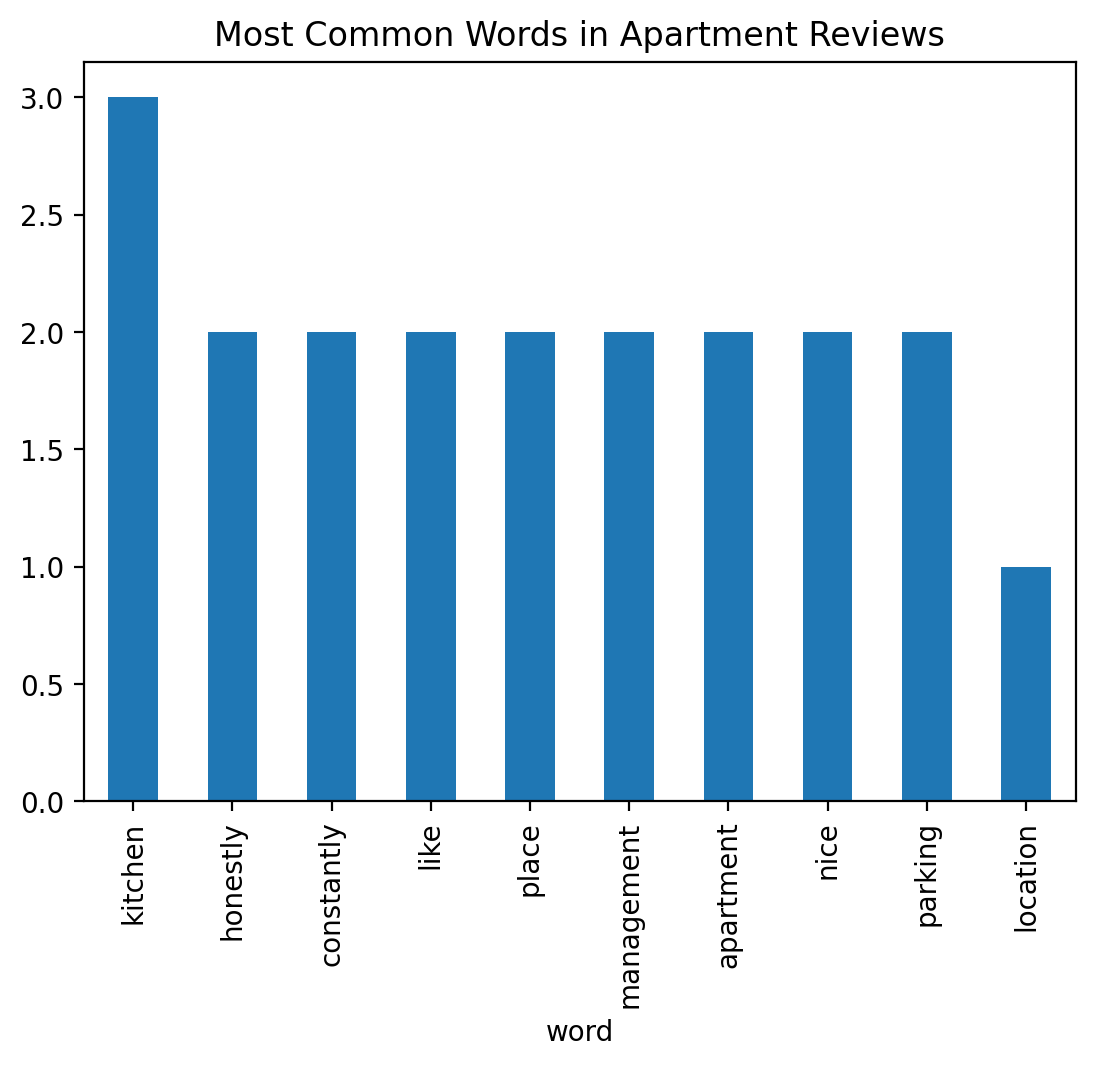

In [13]:
common_words.plot.bar(
    x="word",
    y="count",
    legend=False,
    title="Most Common Words in Apartment Reviews"
)

# You Try

Pick one apartment review and answer:

1.  Does the cleaned version preserve the meaning of the original
    review?
2.  What information was removed?
3.  What information became easier to analyze?

In [14]:
reviews[["Review", "clean_review"]].iloc[[7]].to_string()

'                                                                                                                                                                Review                                                                               clean_review\n7  One night the fire alarm went off three times between midnight and 4am and nobody from management explained what happened. Also saw two cockroaches in the kitchen.  night alarm went times midnight 4am management explained happened saw cockroaches kitchen'

# Limits of Word Counts

Consider these two sentences:

- “dog bites man”
- “man bites dog”

A simple word count treats these as almost identical.

But they clearly mean very different things.

Word order matters.

# Folktales Dataset

Now let’s move to a larger and more complicated text dataset.

In [15]:
folktales = pd.read_csv("data/folktales.csv")

folktales["Country of Origin"].head()

0    Germany
1    Germany
2    Germany
3    Germany
4    Germany
Name: Country of Origin, dtype: object

# Exploring the Dataset

In [16]:
folktales.columns

Index(['Unnamed: 0', 'ATU Code', 'Author', 'Country of Origin',
       'Original Title', 'Source', 'Story', 'Story Type', 'Title',
       'Translated', 'Year Translated', 'Year Written'],
      dtype='object')

In [17]:
folktales["Country of Origin"].value_counts().head(10)

Country of Origin
Greece              202
Germany             159
Denmark             138
Italy               115
Norway               99
France               79
Russia               58
Spain                 9
Iceland               6
Spain   - Region      6
Name: count, dtype: int64

In [18]:
folktales[["Title", "Author", "Country of Origin", "Story Type"]].head()

,Title,Author,Country of Origin,Story Type
0,Cat and mouse in partnership,Jacob & Wilhelm Grimm,Germany,Stealing the Partner's Butter (ATU 15)\n\t\t
1,The Wolf and the Seven Young Kids,Jacob & Wilhelm Grimm,Germany,The Wolf and the Seven Young Kids (ATU 123)\n...
2,Trusty John,Jacob & Wilhelm Grimm,Germany,The Petrified Friend (ATU 516)\n\t\t
3,The good bargain,Jacob & Wilhelm Grimm,Germany,NaN
4,The Wonderful Musician,Jacob & Wilhelm Grimm,Germany,Music lessons for wild animals (ATU 151)\n\t\t


# Select a Familiar Story

We’ll focus on Cinderella because:

- it is culturally recognizable
- it contains repeated motifs
- it is long enough for analysis
- it has strong thematic vocabulary

In [19]:
cinderella = folktales[
    folktales["Title"].str.contains(
        "Cinderella",
        case=False,
        na=False
    )
]

cinderella[["Title","Country of Origin", "Author", "Story Type"]]

,Title,Country of Origin,Author,Story Type
13,Cinderella,Germany,Jacob & Wilhelm Grimm,NaN
427,"Cinderella; or, The Little Glass Slipper",France,Charles Perrault,Persecuted Heroine (ATU 510A)\n\t\t


# Extract Story Text

In [20]:
story = cinderella.iloc[0]["Story"]

story[:1000]

'There was once a rich man whose wife lay sick, and when she felt her end drawing near she called to her only daughter to come near her bed, and said, "Dear child, be pious and good, and God will always take care of you, and I will look down upon you from heaven, and will be with you." And then she closed her eyes and expired. The maiden went every day to her mother\'s grave and wept, and was always pious and good. When the winter came the snow covered the grave with a white covering, and when the sun came in the early spring and melted it away, the man took to himself another wife.The new wife brought two daughters home with her, and they were beautiful and fair in appearance, but at heart were, black and ugly. And then began very evil times for the poor step-daughter. "Is the stupid creature to sit in the same room with us?" said they; "those who eat food must earn it. Out upon her for a kitchen-maid!" They took away her pretty dresses, and put on her an old grey kirtle, and gave her

# Clean the Story

In [21]:
story_clean = story.lower()

In [22]:
story_clean = story_clean.translate(
    str.maketrans(
        string.punctuation,
        " " * len(string.punctuation)
    )
)
story_clean = " ".join(story_clean.split())

story_clean[:1000]

'there was once a rich man whose wife lay sick and when she felt her end drawing near she called to her only daughter to come near her bed and said dear child be pious and good and god will always take care of you and i will look down upon you from heaven and will be with you and then she closed her eyes and expired the maiden went every day to her mother s grave and wept and was always pious and good when the winter came the snow covered the grave with a white covering and when the sun came in the early spring and melted it away the man took to himself another wife the new wife brought two daughters home with her and they were beautiful and fair in appearance but at heart were black and ugly and then began very evil times for the poor step daughter is the stupid creature to sit in the same room with us said they those who eat food must earn it out upon her for a kitchen maid they took away her pretty dresses and put on her an old grey kirtle and gave her wooden shoes to wear just look

In [23]:
story_clean = " ".join(
    word for word in story_clean.split()
    if word not in stopwords
)

story_clean[:1000]

'rich man wife lay sick felt end drawing near called daughter come near bed said dear child pious good god care look heaven closed eyes expired maiden went day mother s grave wept pious good winter came snow covered grave white covering sun came early spring melted away man took wife new wife brought daughters home beautiful fair appearance heart black ugly began evil times poor step daughter stupid creature sit room said eat food earn kitchen maid took away pretty dresses old grey kirtle gave wooden shoes wear just look proud princess decked cried laughing sent kitchen obliged heavy work morning night early morning draw water make fires cook wash sisters did utmost torment mocking strewing peas lentils ashes setting pick evenings quite tired hard day s work bed lie obliged rest hearth cinders looked dusty dirty named cinderella happened day father went fair asked step daughters bring fine clothes said pearls jewels said cinderella said twig father strikes hat way home like bring bough

# Word Frequencies

In [24]:
story_words = story_clean.split()

Counter(story_words).most_common(20)

[('cinderella', 24),
 ('went', 18),
 ('said', 17),
 ('shoe', 17),
 ('came', 15),
 ('prince', 15),
 ('mother', 14),
 ('pick', 13),
 ('tree', 13),
 ('step', 12),
 ('s', 11),
 ('bride', 11),
 ('maiden', 10),
 ('home', 10),
 ('cried', 10),
 ('doves', 10),
 ('ashes', 9),
 ('hazel', 9),
 ('little', 9),
 ('right', 9)]

These are some of the most common meaningful words in the story.

In [25]:
cinderella_words = pd.DataFrame(
    Counter(story_words).most_common(15),
    columns=["word", "count"]
)

<Axes: title={'center': 'Most Common Words in Cinderella'}, xlabel='word'>

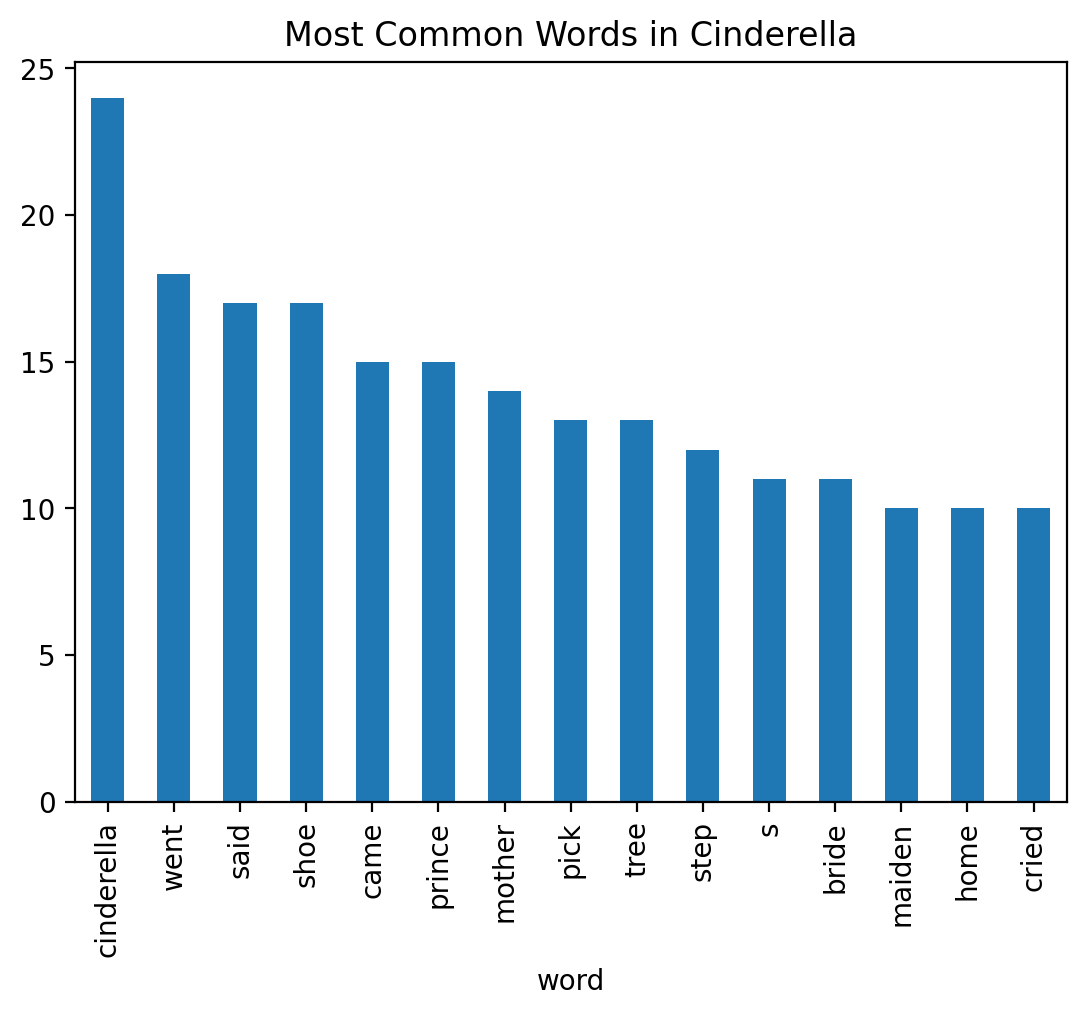

In [26]:
cinderella_words.plot.bar(
    x="word",
    y="count",
    legend=False,
    title="Most Common Words in Cinderella"
)

# N-grams

Single words can be useful, but phrases can reveal more structure.

An n-gram is a sequence of words.

Today we will focus on:

- bigrams, or 2-word phrases

In [27]:
from nltk import ngrams

In [28]:
bigrams = list(
    ngrams(story_words, 2)
)

Counter(bigrams).most_common(15)

[(('pick', 'peck'), 8),
 (('lentils', 'ashes'), 7),
 (('hazel', 'bush'), 7),
 (('step', 'mother'), 6),
 (('little', 'tree'), 6),
 (('mother', 's'), 4),
 (('s', 'grave'), 4),
 (('cinderella', 'went'), 4),
 (('king', 's'), 4),
 (('turtle', 'doves'), 4),
 (('began', 'pick'), 4),
 (('peck', 'pick'), 4),
 (('tree', 'little'), 4),
 (('pigeon', 'house'), 4),
 (('right', 'bride'), 4)]

# Why N-grams Matter

N-grams preserve some word order information.

For example:

- “king's son”
- “touched wand”
- “glass slippers”

can reveal themes that single words might miss.

# TF-IDF

Word frequency tells us what words are common.

But what words make a story unique?

TF-IDF helps identify words that are:

- common in one document
- uncommon across the whole collection

In plain language:

- **TF** asks: What words appear often in this story?
- **IDF** asks: What words are rare across all stories?
- **TF-IDF** asks: What words help make this story distinctive?

This idea is closely related to how search engines and recommendation
systems identify important terms in documents.

# TF-IDF with Scikit-Learn

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [30]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

In [31]:
matrix = tfidf.fit_transform(
    folktales["Story"].fillna("")
)

In [32]:
matrix.shape

(908, 5000)

# Most Important Words in Cinderella

In [33]:
# The dataset contains multiple versions of Cinderella.
# We'll use the French version because it is closer to the version
# most readers recognize today and contains many familiar story elements.
story_index = cinderella.index[1]

In [34]:
feature_names = tfidf.get_feature_names_out()

scores = matrix[story_index].toarray()[0]

important_words = pd.DataFrame({
    "word": feature_names,
    "score": scores
})

important_words.sort_values(
    by="score",
    ascending=False
).head(20)

,word,score
742,cinderella,0.694117
1864,godmother,0.382865
248,ball,0.211740
3949,sisters,0.184815
3983,slipper,0.141701
3372,pumpkin,0.095716
4775,wand,0.093895
300,beautiful,0.093479
794,coach,0.082671
1576,fine,0.082283


# Compare Word Frequency and TF-IDF

<Axes: title={'center': 'Most Distinctive Words in Cinderella by TF-IDF'}, xlabel='word'>

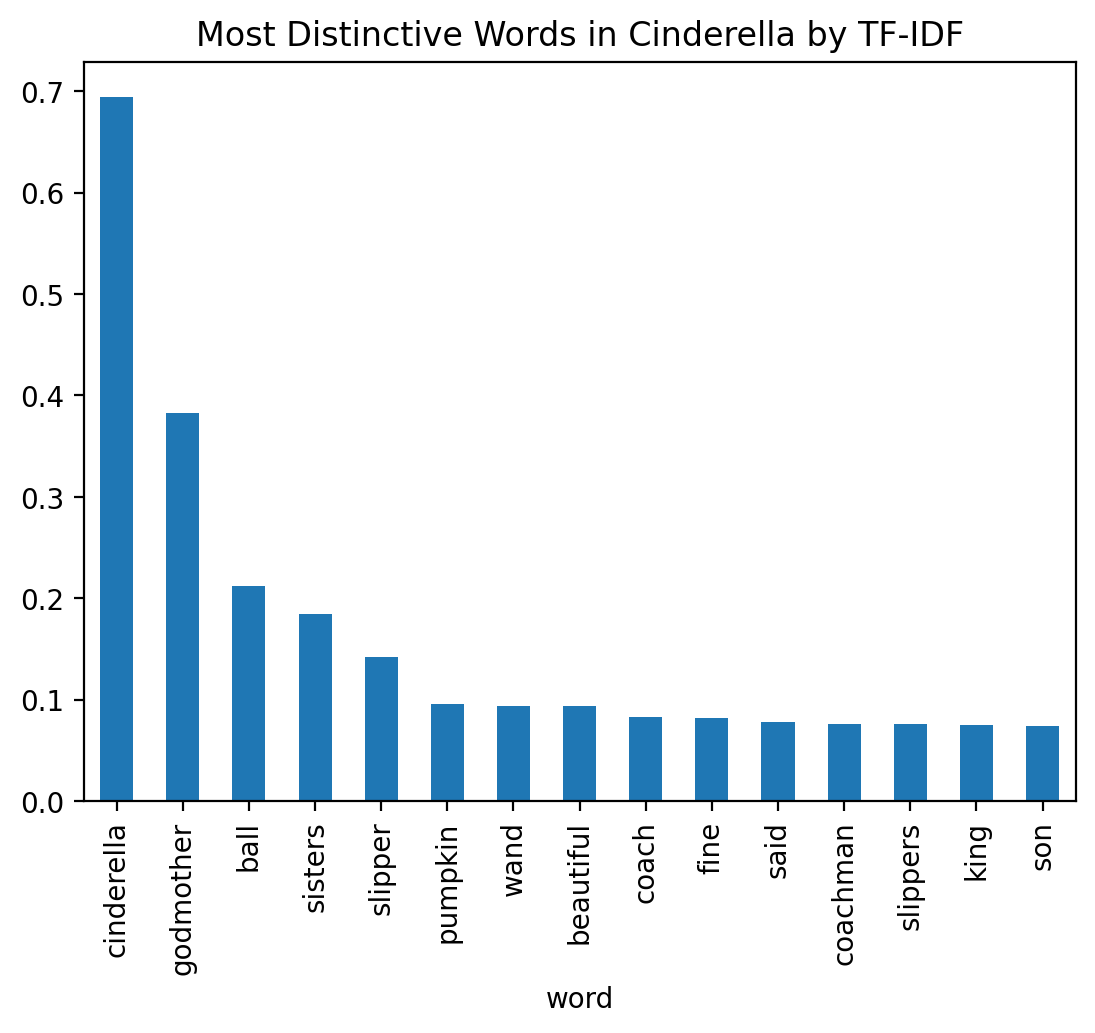

In [35]:
top_tfidf = important_words.sort_values(
    by="score",
    ascending=False
).head(15)

top_tfidf.plot.bar(
    x="word",
    y="score",
    legend=False,
    title="Most Distinctive Words in Cinderella by TF-IDF"
)

# Comparing Cinderella and Little Red Riding Hood

TF-IDF becomes especially useful when we compare documents.

Let's compare two familiar stories:

- Cinderella
- Little Red Riding Hood

We expect different stories to have different distinctive words.

In [36]:
little_red = folktales[
    folktales["Title"].str.contains(
        "Little Red",
        case=False,
        na=False
    )
]

little_red[["Title", "Country of Origin", "Author", "Story Type"]]

,Title,Country of Origin,Author,Story Type
18,Little Red Riding Hood,Germany,Jacob & Wilhelm Grimm,Little Red Riding Hood (ATU 333)
423,Little Red Riding Hood,France,Charles Perrault,Little Red Riding Hood (ATU 333)\n\t\t


In [37]:
# We'll compare against the French version of Little Red Riding Hood
# for the same reason.
little_red_index = little_red.index[1]


In [38]:
# Get Cinderella TF-IDF scores
cinderella_scores = matrix[story_index].toarray()[0]

cinderella_tfidf = pd.DataFrame({
    "word": feature_names,
    "score": cinderella_scores
}).sort_values(
    by="score",
    ascending=False
).head(15)

cinderella_tfidf

,word,score
742,cinderella,0.694117
1864,godmother,0.382865
248,ball,0.211740
3949,sisters,0.184815
3983,slipper,0.141701
3372,pumpkin,0.095716
4775,wand,0.093895
300,beautiful,0.093479
794,coach,0.082671
1576,fine,0.082283


In [39]:
# Get Little Red Riding Hood TF-IDF scores
little_red_scores = matrix[little_red_index].toarray()[0]

little_red_tfidf = pd.DataFrame({
    "word": feature_names,
    "score": little_red_scores
}).sort_values(
    by="score",
    ascending=False
).head(15)

little_red_tfidf

,word,score
2140,hood,0.456463
1897,grandmother,0.419637
4917,wolf,0.365725
3584,riding,0.305306
2530,little,0.226362
3479,red,0.222231
587,cake,0.177792
571,butter,0.166112
4388,tap,0.148279
3264,pot,0.131108


## Visual Comparison

<Axes: title={'center': 'Distinctive Words in Cinderella'}, xlabel='word'>

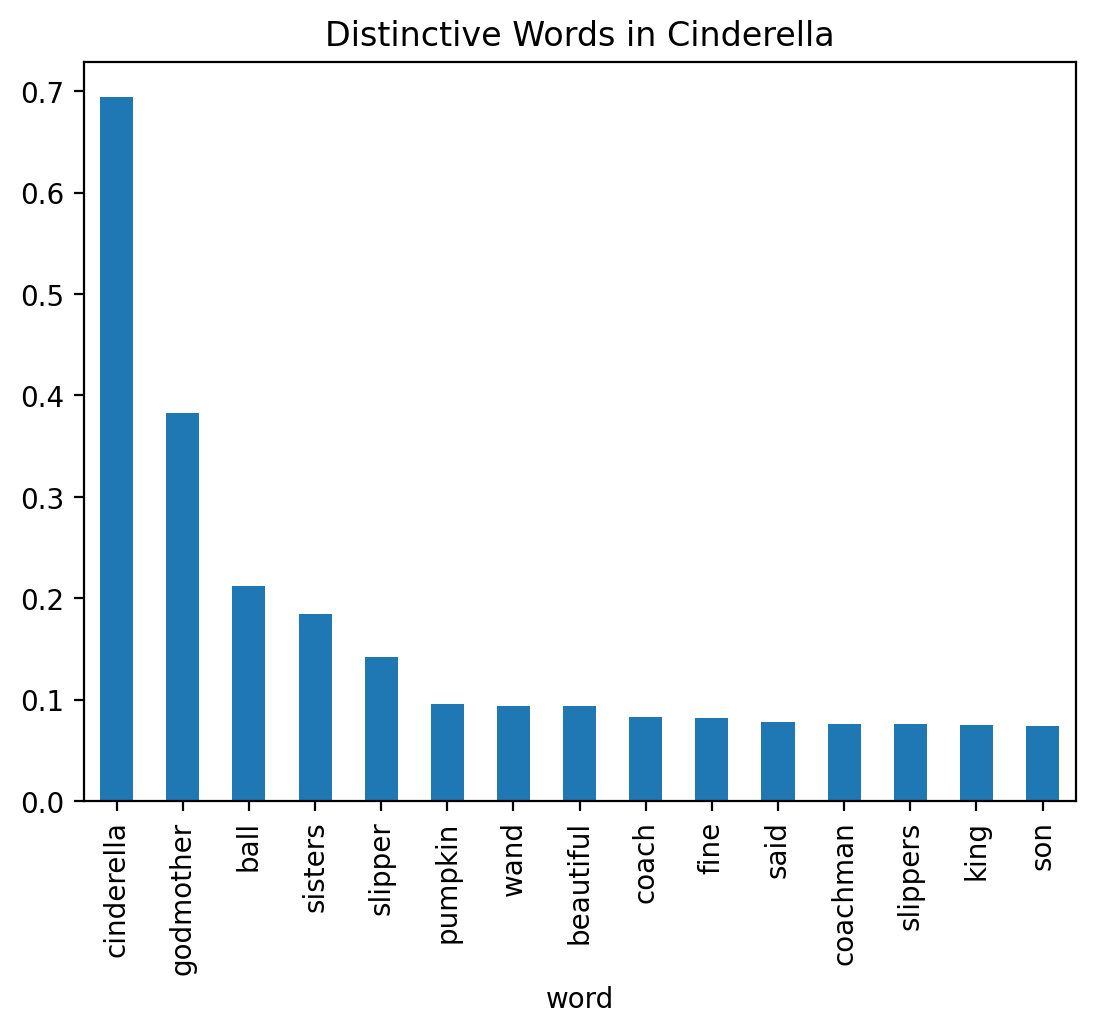

In [40]:
cinderella_tfidf.plot.bar(
    x="word",
    y="score",
    legend=False,
    title="Distinctive Words in Cinderella"
)

<Axes: title={'center': 'Distinctive Words in Little Red Riding Hood'}, xlabel='word'>

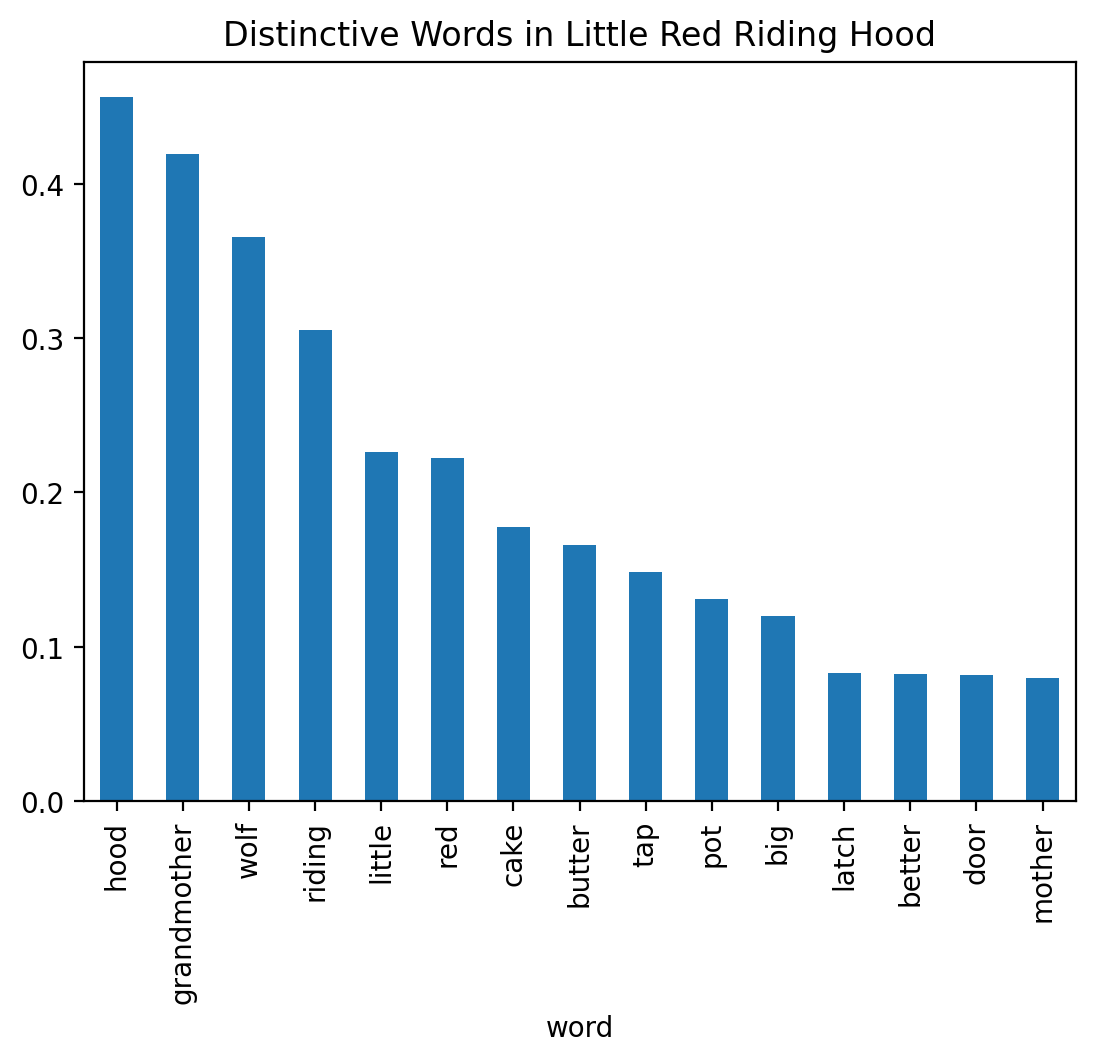

In [41]:
little_red_tfidf.plot.bar(
    x="word",
    y="score",
    legend=False,
    title="Distinctive Words in Little Red Riding Hood"
)

# You Try

Choose a different folktale and repeat the TF-IDF analysis.

In [42]:
folktales[["Title", "Country of Origin"]].sample(10)

,Title,Country of Origin
761,The Sacrilegious Thief,Italy
529,The Bear and the Two Travelers,Greece
268,The comet,Denmark
45,The Dog and the Sparrow,Germany
253,The snowdrop,Denmark
640,The Geese and the Cranes,Greece
111,The old man made young again,Germany
893,The City Mouse and the Country Mouse,Greece
552,The Shepherd and the Wolf,Greece
526,"The Ass, the Fox, and the Lion",Greece


In [43]:
# Change this title fragment to find a different story
title_fragment = "girl"

selected_story = folktales[
    folktales["Title"].str.contains(
        title_fragment,
        case=False,
        na=False
    )
]

selected_story[["Title", "Country of Origin", "Author"]].head()

,Title,Country of Origin,Author
23,The girl without hands,Germany,Jacob & Wilhelm Grimm
72,The goose girl,Germany,Jacob & Wilhelm Grimm
129,The goose-girl at the well,Germany,Jacob & Wilhelm Grimm
222,The Jewish girl,Denmark,H.C. Andersen
235,The girl who trod on the loaf,Denmark,H.C. Andersen


In [44]:
story = selected_story.iloc[4]["Story"]

story

'There was once a girl who trod on a loaf to avoid soiling her shoes, and the misfortunes that happened to her in consequence are well known.Her name was Inge; she was a poor child, but proud and presuming, and with a bad and cruel disposition. When quite a little child she would delight in catching flies, and tearing off their wings, so as to make creeping things of them. When older, she would take cockchafers and beetles, and stick pins through them. Then she pushed a green leaf, or a little scrap of paper towards their feet, and when the poor creatures would seize it and hold it fast, and turn over and over in their struggles to get free from the pin, she would say, "The cockchafer is reading; see how he turns over the leaf." She grew worse instead of better with years, and, unfortunately, she was pretty, which caused her to be excused, when she should have been sharply reproved."Your headstrong will requires severity to conquer it," her mother often said to her. "As a little child 

In [45]:
# If the search found at least one story, analyze the first match
selected_index = selected_story.index[4]

selected_scores = matrix[selected_index].toarray()[0]

selected_important_words = pd.DataFrame({
    "word": feature_names,
    "score": selected_scores
})

selected_important_words.sort_values(
    by="score",
    ascending=False
).head(20)

,word,score
2239,inge,0.853086
2543,loaf,0.185294
2659,marsh,0.106026
382,bird,0.103301
713,child,0.102801
4408,tears,0.088657
2798,mother,0.075716
4919,woman,0.074715
1321,earth,0.067579
383,birds,0.066760


# Simple Sentiment Analysis

Another common text analysis task is sentiment analysis.

This attempts to estimate whether text is:

- positive
- negative
- neutral

Sentiment analysis is useful, but it is also imperfect. It can struggle
with sarcasm, context, older language, and cultural nuance.

In [46]:
from textblob import TextBlob

In [96]:
pip install textblob

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.0/625.0 kB 7.5 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [47]:
reviews["sentiment"] = reviews["Review"].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

reviews[["Apartment","Stars","sentiment"]]

,Apartment,Stars,sentiment
0,Mustang Station,2,0.146667
1,Campus View,4,0.086111
2,Highland House,1,0.090909
3,Mockingbird Flats,5,0.333333
4,Hilltop Lofts,3,-0.116667
5,University Crossing,2,0.066667
6,Maple Terrace,4,0.180952
7,Lakeside Apartments,1,0.000000


<Axes: title={'center': 'Estimated Review Sentiment'}, xlabel='Apartment'>

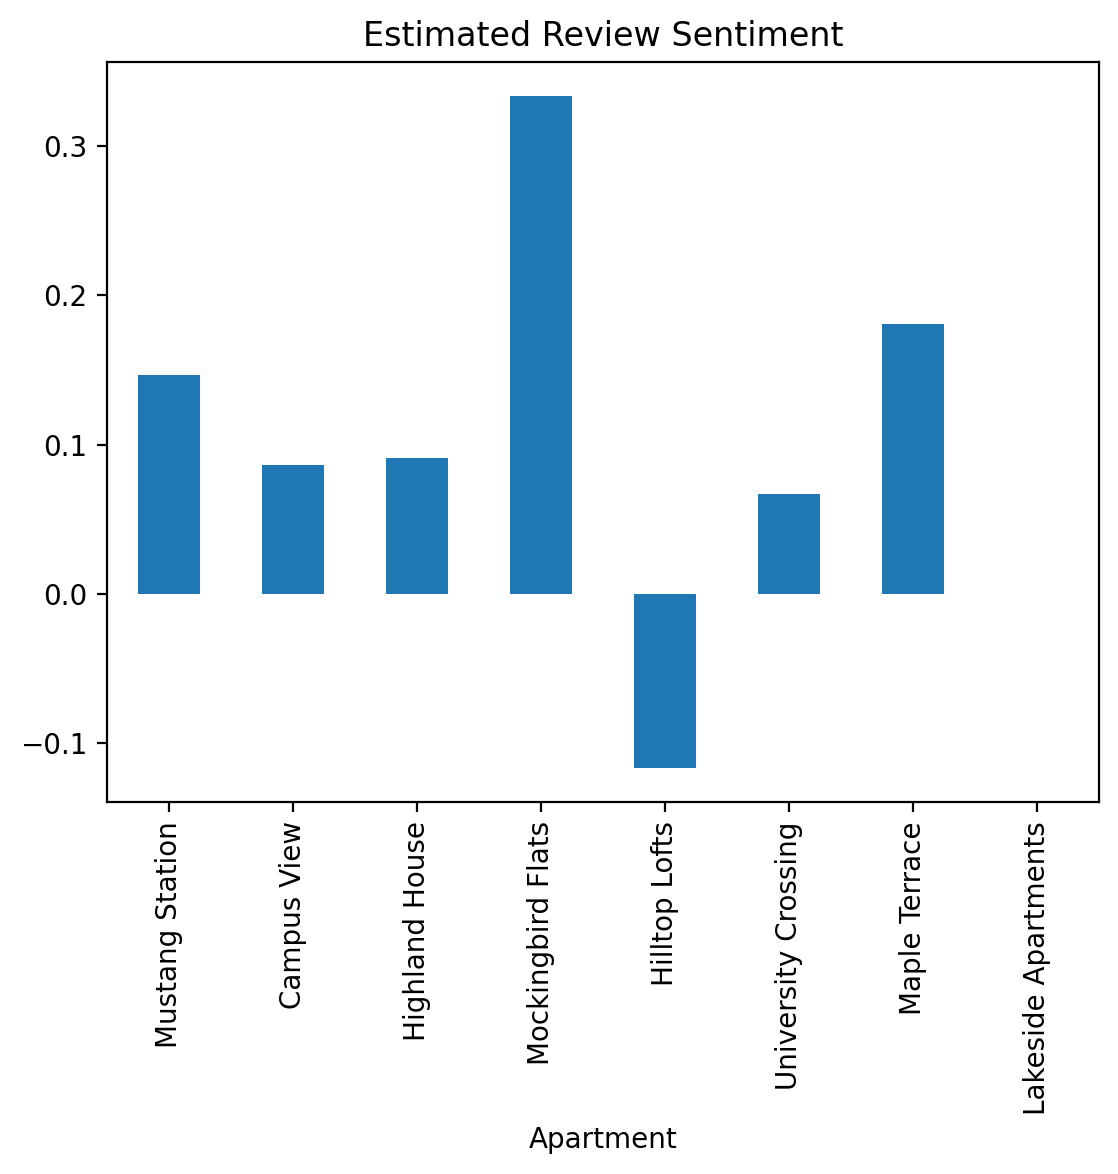

In [48]:
reviews.plot.bar(
    x="Apartment",
    y="sentiment",
    legend=False,
    title="Estimated Review Sentiment"
)

# Sentiment in Folktales

In [49]:
folktales["sentiment"] = folktales["Story"].fillna("").apply(
    lambda x: TextBlob(x).sentiment.polarity
)

folktales[["Title", "Country of Origin", "sentiment"]].sort_values(
    by="sentiment",
    ascending=False
).head(10)

,Title,Country of Origin,sentiment
513,The Boy Hunting Locusts,Greece,0.875000
735,The Kite and the Doves,Italy,0.800000
562,The Man Bitten by a Dog,Greece,0.700000
671,The Wolf and the Lion,Greece,0.625000
745,The Cock and the Pearl,Italy,0.566667
847,The Rooster and the Gem,France,0.556250
602,The Fox and the Leopard,Greece,0.540000
750,The Trees Protected,Italy,0.529762
535,The Lioness,Greece,0.529167
783,The Man and the Dog,Italy,0.500000


In [50]:
folktales[["Title", "Country of Origin", "sentiment"]].sort_values(
    by="sentiment",
    ascending=True
).head(10)

,Title,Country of Origin,sentiment
77,Old Hildebrand,Germany,-0.345443
670,The Fox and the Bramble,Greece,-0.333333
647,The Gamecocks and the Partridge,Greece,-0.323611
505,The Boy Bathing,Greece,-0.312500
531,The Thirsty Pigeon,Greece,-0.310000
665,Truth and the Traveler,Greece,-0.300000
693,The Frogs' Complaint Against the Sun,Greece,-0.299286
726,The Hungry Dogs,Italy,-0.275000
565,The Aethiop,Greece,-0.255556
773,The Viper and the File,Italy,-0.237500


# Limitations of Text Analysis

Text analysis is powerful, but imperfect.

Some challenges include:

- sarcasm
- ambiguity
- context
- cultural meaning
- humor
- changing language
- translation
- historical language
- missing metadata

Simple methods often lose important meaning.

# AI and Modern Language Models

Many modern AI systems use ideas related to text analysis.

Older approaches:

- counted words
- measured frequencies
- used simple statistics

Modern AI systems:

- model context
- learn relationships between words
- represent language mathematically
- generate new text

Large Language Models are built on these kinds of ideas, but at much
larger scales.

# AI Assistant Checkpoint

Try asking an AI assistant:

- “Explain TF-IDF in plain English.”
- “Why do we remove stopwords in text analysis?”
- “What meaning is lost when we use word counts?”
- “How could I improve this text analysis?”
- “Why might sentiment analysis fail on folktales?”

# Mini Challenge

Choose one folktale or the apartment review set and investigate it.

Try to:

- clean the text
- count important words
- generate bigrams
- calculate TF-IDF
- visualize something interesting

Then answer:

1.  What pattern did you notice?
2.  What surprised you?
3.  What important meaning might your analysis miss?

In [52]:
folktales2 = pd.read_csv("data/folktales.csv")

In [66]:
my_story = folktales[
    folktales["Title"].str.contains(
        "Old",
        case=False,
        na=False
    )
]

In [67]:
my_story[["Title","Country of Origin", "Author", "Story Type"]]

,Title,Country of Origin,Author,Story Type
21,The devil with the three golden hairs,Germany,Jacob & Wilhelm Grimm,Three Hairs of the Devil (ATU 461)\n\t\t
28,"The Wishing-Table, the Gold-Ass, and the Cudge...",Germany,Jacob & Wilhelm Grimm,Three Magic Gifts (ATU 563)\n\t\t
36,Old Sultan,Germany,Jacob & Wilhelm Grimm,The old dog rescues the child (ATU 101)\n\t\t
44,The golden bird,Germany,Jacob & Wilhelm Grimm,The Golden Bird (ATU 550)\n\t\t
51,The golden goose,Germany,Jacob & Wilhelm Grimm,The Golden Goose (ATU 571)\n\t\t
57,Six soldiers of fortune,Germany,Jacob & Wilhelm Grimm,The Wonderful Helpers (ATU 513A)\n\t\t
68,The gold-children,Germany,Jacob & Wilhelm Grimm,"The Fisherman and his Wife, (ATU 555)\n\t\t"
75,The king of the golden mountain,Germany,Jacob & Wilhelm Grimm,The devil loses a soul that was promised him ...
77,Old Hildebrand,Germany,Jacob & Wilhelm Grimm,NaN
90,The old woman in the wood,Germany,Jacob & Wilhelm Grimm,The Old Woman in the Wood (ATU 442)\n\t\t


In [68]:
story = my_story.iloc[8]["Story"]

story

'Once upon a time lived a peasant and his wife, and the parson of the village had a fancy for the wife, and had wished for a long while to spend a whole day happily with her. The peasant woman, too, was quite willing. One day, therefore, he said to the woman, "Listen, my dear friend, I have now thought of a way by which we can for once spend a whole day happily together. I\'ll tell you what; on Wednesday, you must take to your bed, and tell your husband you are ill, and if you only complain and act being ill properly, and go on doing so until Sunday when I have to preach, I will then say in my sermon that whosoever has at home a sick child, a sick husband, a sick wife, a sick father, a sick mother, a sick brother or whosoever else it may be, and makes a pilgrimage to the Göckerli hill in Italy, where you can get a peck of laurel-leaves for a kreuzer, the sick child, the sick husband, the sick wife, the sick father, or sick mother, the sick sister, or whosoever else it may be, will be r

In [69]:
story_clean = story.lower()

In [70]:
story_clean = story_clean.translate(
    str.maketrans(
        string.punctuation,
        " " * len(string.punctuation)
    )
)
story_clean = " ".join(story_clean.split())

story_clean[:1000]

'once upon a time lived a peasant and his wife and the parson of the village had a fancy for the wife and had wished for a long while to spend a whole day happily with her the peasant woman too was quite willing one day therefore he said to the woman listen my dear friend i have now thought of a way by which we can for once spend a whole day happily together i ll tell you what on wednesday you must take to your bed and tell your husband you are ill and if you only complain and act being ill properly and go on doing so until sunday when i have to preach i will then say in my sermon that whosoever has at home a sick child a sick husband a sick wife a sick father a sick mother a sick brother or whosoever else it may be and makes a pilgrimage to the göckerli hill in italy where you can get a peck of laurel leaves for a kreuzer the sick child the sick husband the sick wife the sick father or sick mother the sick sister or whosoever else it may be will be restored to health immediately i wil

In [71]:
story_clean = " ".join(
    word for word in story_clean.split()
    if word not in stopwords
)

story_clean[:1000]

'time lived peasant wife parson village fancy wife wished long spend day happily peasant woman quite willing day said woman listen dear friend thought way spend day happily ll tell wednesday bed tell husband ill complain act ill properly doing sunday preach say sermon whosoever home sick child sick husband sick wife sick father sick mother sick brother whosoever makes pilgrimage göckerli hill italy peck laurel leaves kreuzer sick child sick husband sick wife sick father sick mother sick sister whosoever restored health immediately manage said woman promptly wednesday peasant woman took bed complained lamented agreed husband did think did good sunday came woman said feel ill going die thing like end like hear parson s sermon going preach day peasant said ah child thou mightest make thyself worse thou wert look sermon attend carefully tell thee parson says said woman pay great attention repeat thou hearest peasant went sermon parson began preach said home sick child sick husband sick wif

In [72]:
story_words = story_clean.split()

Counter(story_words).most_common(20)

[('sick', 48),
 ('parson', 16),
 ('said', 16),
 ('peasant', 13),
 ('wife', 13),
 ('woman', 13),
 ('husband', 11),
 ('gossip', 11),
 ('child', 9),
 ('thou', 9),
 ('day', 8),
 ('whosoever', 8),
 ('father', 8),
 ('mother', 8),
 ('laurel', 8),
 ('kreuzer', 8),
 ('home', 7),
 ('brother', 7),
 ('leaves', 7),
 ('sister', 7)]

In [73]:
words = pd.DataFrame(
    Counter(story_words).most_common(15),
    columns=["word", "count"]
)

<Axes: title={'center': 'Most Common Words in Old Hildebrand'}, xlabel='word'>

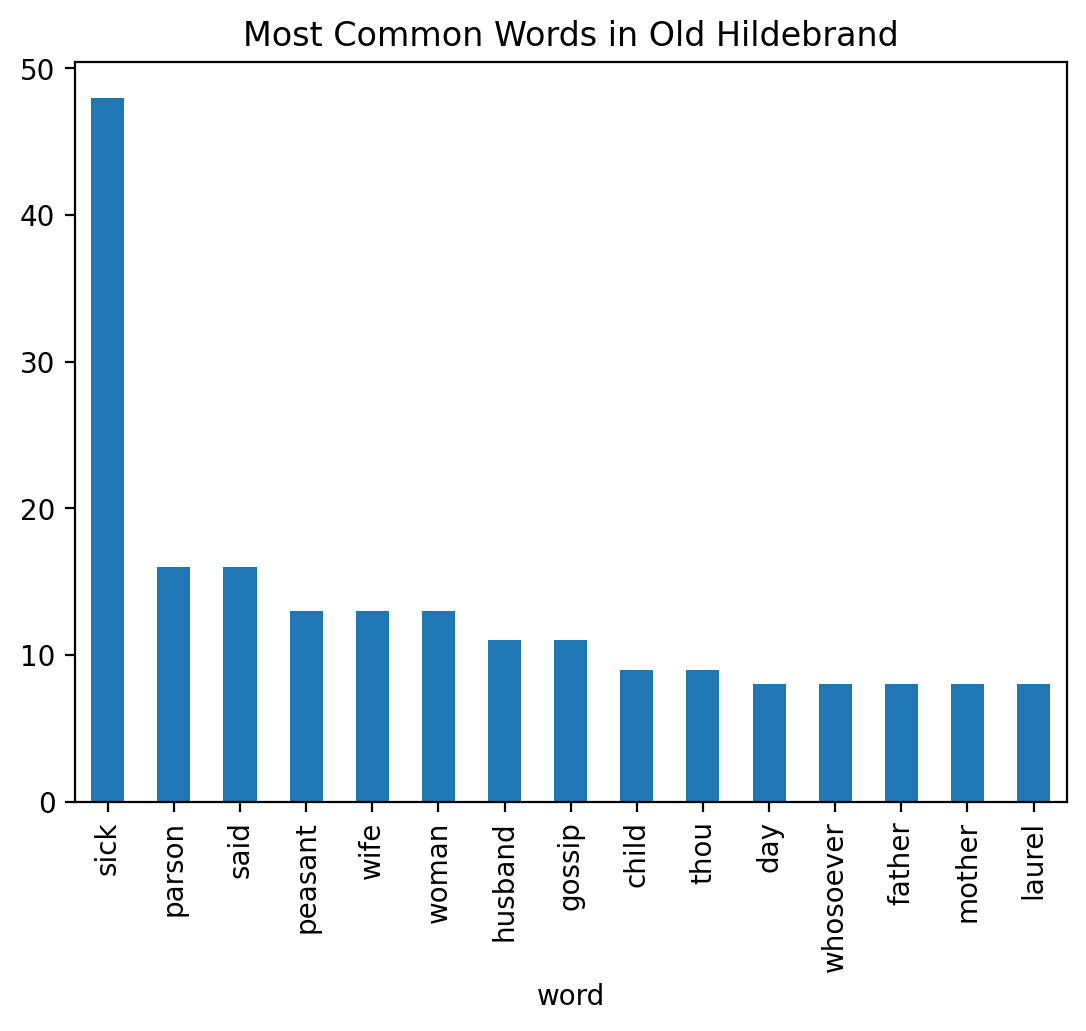

In [74]:
words.plot.bar(
    x="word",
    y="count",
    legend=False,
    title="Most Common Words in Old Hildebrand"
)

In [75]:
bigrams = list(
    ngrams(story_words, 2)
)

Counter(bigrams).most_common(15)

[(('sick', 'child'), 8),
 (('child', 'sick'), 8),
 (('sick', 'husband'), 8),
 (('husband', 'sick'), 8),
 (('sick', 'wife'), 8),
 (('wife', 'sick'), 8),
 (('sick', 'father'), 8),
 (('father', 'sick'), 8),
 (('sick', 'mother'), 8),
 (('mother', 'sick'), 8),
 (('laurel', 'leaves'), 7),
 (('sick', 'sister'), 7),
 (('göckerli', 'hill'), 6),
 (('sister', 'brother'), 6),
 (('said', 'woman'), 5)]

In [76]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

In [77]:
matrix = tfidf.fit_transform(
    folktales2["Story"].fillna("")
)

In [78]:
story_index = my_story.index[8]

In [79]:
feature_names = tfidf.get_feature_names_out()

scores = matrix[story_index].toarray()[0]

important_words = pd.DataFrame({
    "word": feature_names,
    "score": scores
})

important_words.sort_values(
    by="score",
    ascending=False
).head(20)

,word,score
3907,sick,0.699974
3045,parson,0.317684
1880,gossip,0.218408
2381,kreuzer,0.211602
3090,peasant,0.188743
2435,laurel,0.184897
4871,whosoever,0.136996
4919,woman,0.118157
2201,husband,0.117025
4877,wife,0.112450


<Axes: title={'center': 'Most Distinctive Words in Old Hildebrand by TF-IDF'}, xlabel='word'>

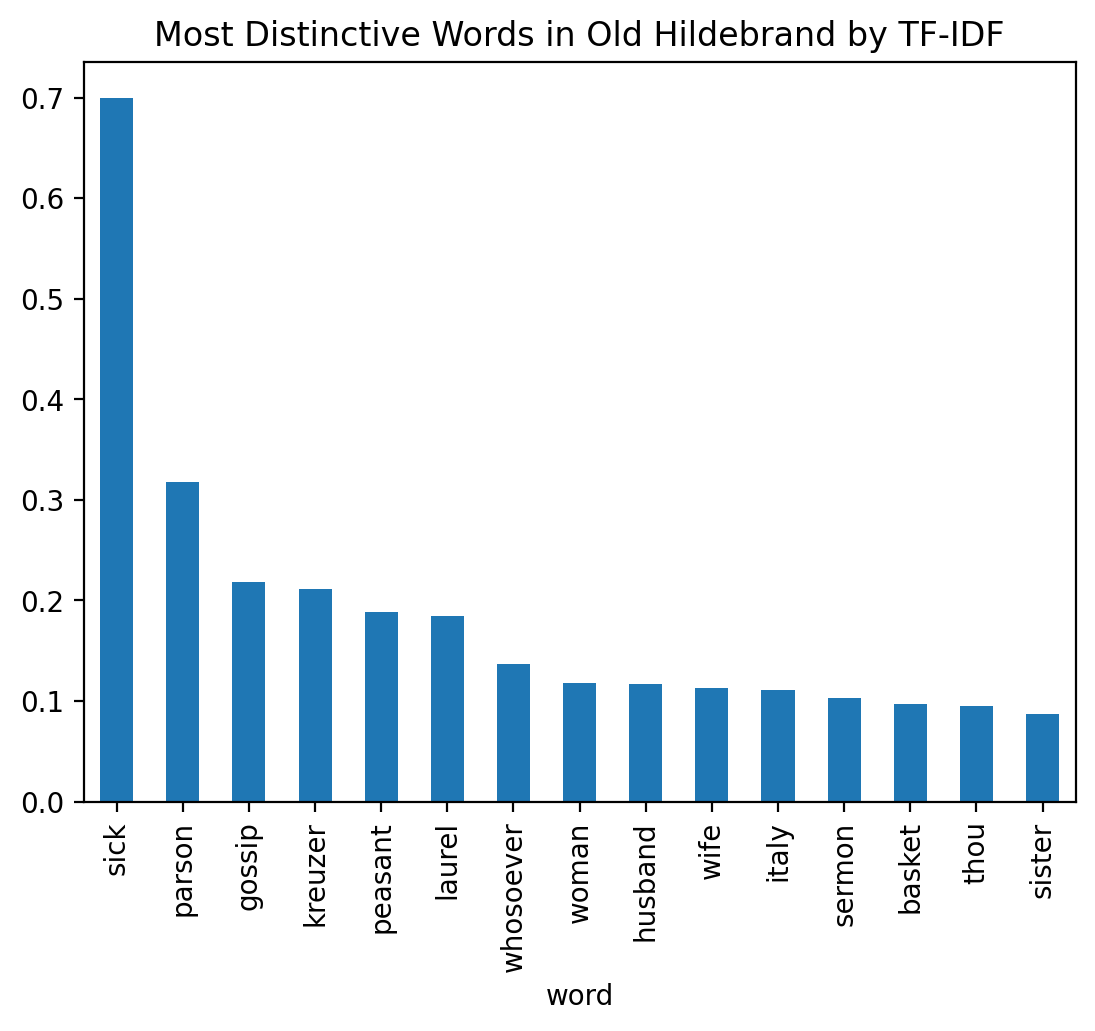

In [80]:
top_tfidf = important_words.sort_values(
    by="score",
    ascending=False
).head(15)

top_tfidf.plot.bar(
    x="word",
    y="score",
    legend=False,
    title="Most Distinctive Words in Old Hildebrand by TF-IDF"
)